# Let us understand the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')

In [ ]:
df = pd.read_csv("../data/raw/flight_data.csv")

# Dataset overview


In [3]:
df.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


In [5]:
df.describe()

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


In [6]:
df.duplicated().sum()

np.int64(0)

### Anomaly Scan - finding gaps and anomaly in the data

In [7]:
df.loc[ ~df["flight"].str.match(r"[A-Z 0-9]{2}-[0-9]{2,4}",na=False),"flight"].unique()

array(['0.00E+00', '6.00E-219', '6.00E-282', '6.00E-161', '6.00E-126',
       '6.00E-146', '6.00E-139', '6.00E-128', '0.00E-02', '6.00E-135',
       '6.00E-136', '6.00E-113', '6.00E-149', '6.00E-232', '6.00E-234',
       '6.00E-181', '6.00E-132', '6.00E-269', '6.00E-285', '6.00E-218',
       '6.00E-157', '6.00E-201', '6.00E-207', '6.00E-168', '6.00E-295',
       '6.00E-152', '6.00E-276', '6.00E-186', '6.00E-177', '6.00E-154',
       '6.00E-156', '6.00E-121', '6.00E-176', '6.00E-255', '6.00E-171',
       '6.00E-246', '6.00E-236', '6.00E-102', '6.00E-138', '6.00E-183',
       '6.00E-179', '6.00E-296', '6.00E-193', '6.00E-164', '6.00E-294',
       '6.00E-292', '6.00E-227', '6.00E-134', '6.00E-307', '6.00E-165',
       '6.00E-248', '6.00E-198', '6.00E-283', '6.00E-188', '6.00E-205',
       '6.00E-131', '6.00E-286', '6.00E-224', '6.00E-271', '6.00E-184',
       '6.00E-153', '6.00E-289', '6.00E-244', '6.00E-221', '6.00E-308',
       '6.00E-192', '6.00E-268', '6.00E-298', '6.00E-151', '6.00E-

# Missing value analysis

In [8]:
df.isnull().sum()


,0
id,0
airline,4613
flight,0
source,0
departure,4792
stops,2319
arrival,0
destination,0
class,0
duration,3013


- The dataset has 12 columns out of which we have one target variable called "price".
- The dataset has 4 numerical and 8 cateforical features.
- There are 5 columns with missing values

# Outlier analysis

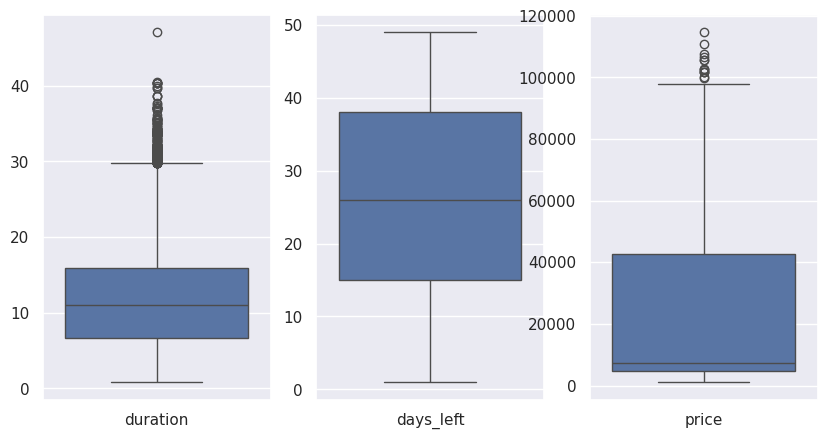

In [9]:
plt.figure(figsize=(10, 5))

plt.subplot(1,3,1)
sns.boxplot(data=df[['duration']])
plt.subplot(1,3,2)
sns.boxplot(data=df[['days_left']])
plt.subplot(1,3,3)
sns.boxplot(data=df[[ 'price']])
plt.show()

# Target analysis

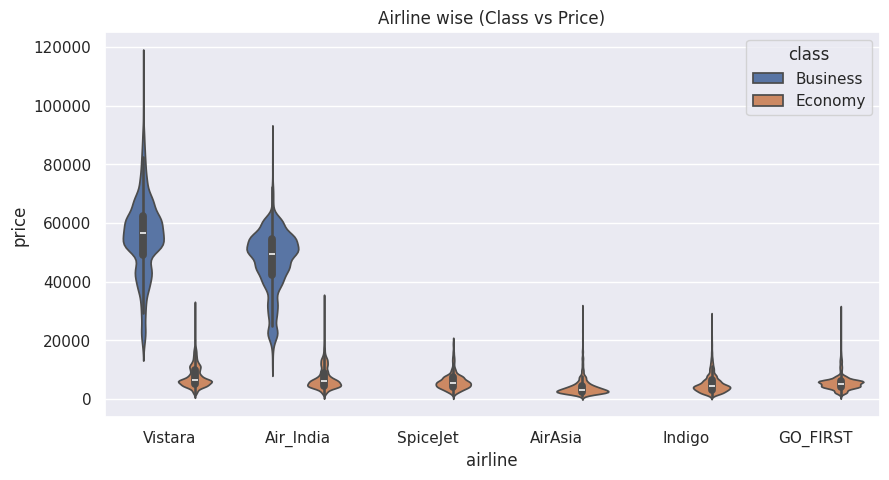

In [10]:

plt.figure(figsize=(10, 5))

sns.violinplot(data=df, x='airline',y='price',hue='class')
plt.title('Airline wise (Class vs Price)')

plt.show()

📌 **Observation** - in this dataset only two 'airline' has bothe the classes ('Business','Economy'), and we can observe the price difference of the tickets between classes

# Correlation analysis

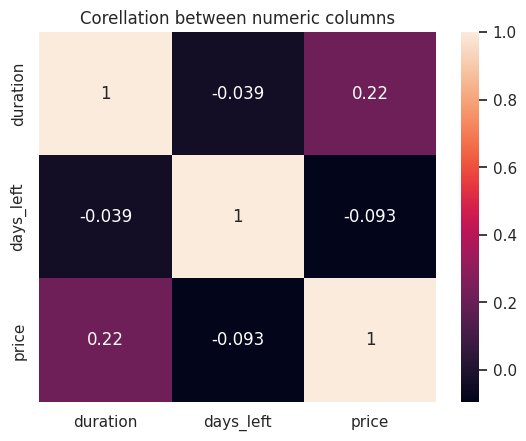

In [11]:
sns.heatmap(df[['duration','days_left','price']].corr(), annot=True)
plt.title('Corellation between numeric columns')
plt.show()

### 📌 Observation - there is a corealiation between the duration of the flight and the price of the ticket. We can take duration as proxy for distance.
- price has higher corellation with duration, but the data set has missing value in the duration column

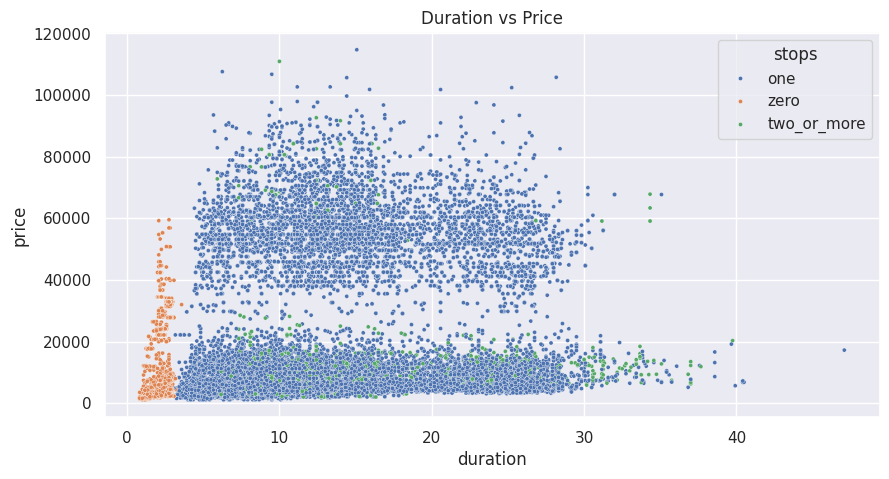

In [12]:
# Duration vs Price
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df,x='duration', y='price',hue='stops',s=9)

plt.title('Duration vs Price')
plt.show()

### 📌 Observation - from the above visualization, it is clear that the price of the route with 'two_or_more' is lower, and the routes with 'one' stop is in the higher side. and routes with 'zero' stops are of short duration
- the graph suggest , we should not use mean() for the data imputation , mode() is the better choise for this dataset

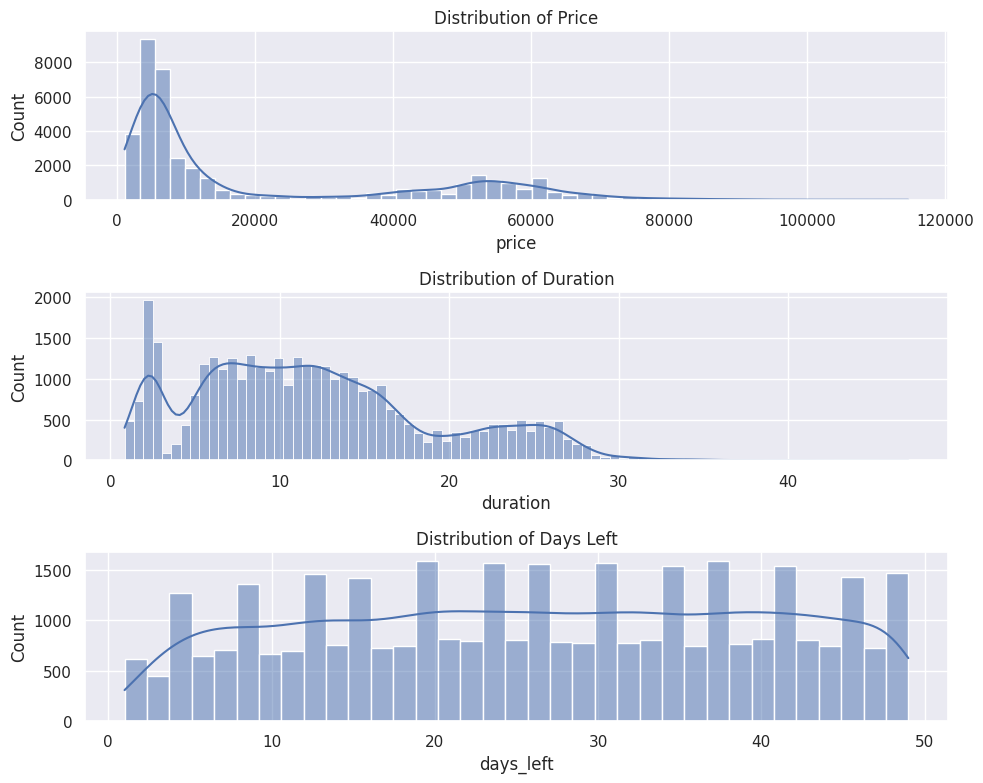

In [ ]:

plt.figure(figsize=(10, 8))

# 1: Price
plt.subplot(3, 1, 1)
sns.histplot(data=df, x='price', kde=True)
plt.title('Distribution of Price')

# 2: Duration
plt.subplot(3, 1, 2)
sns.histplot(data=df, x='duration', kde=True)
plt.title('Distribution of Duration')

#  3: Days Left (Fixed syntax error here)
plt.subplot(3, 1, 3)
sns.histplot(data=df, x='days_left', kde=True)
plt.title('Distribution of Days Left')


plt.tight_layout()

plt.show()


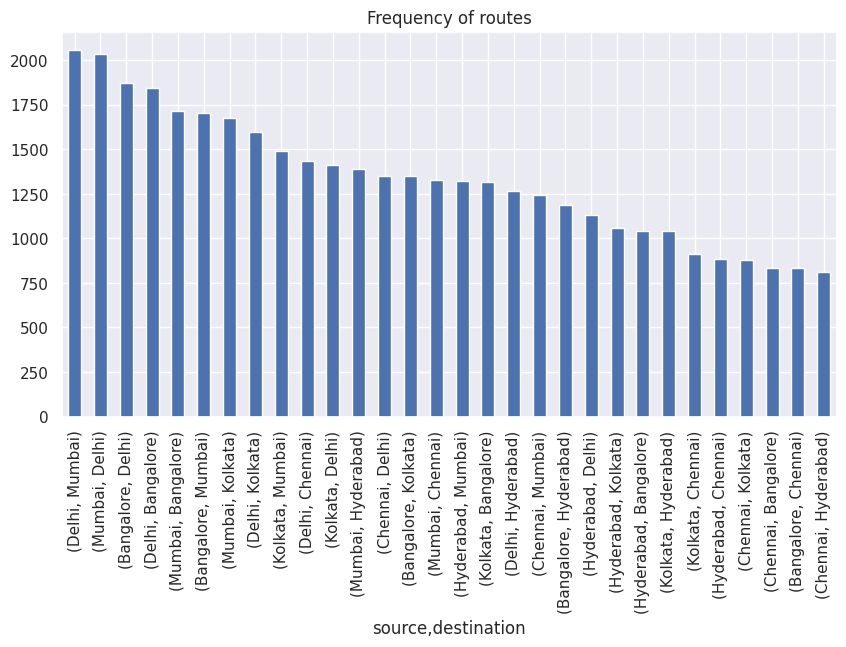

In [28]:
plt.figure(figsize=(10, 5))

# route frequency
df.groupby(['source','destination'])['price'].count().sort_values(ascending=False).plot(kind='bar')
plt.title("Frequency of routes")
plt.show()

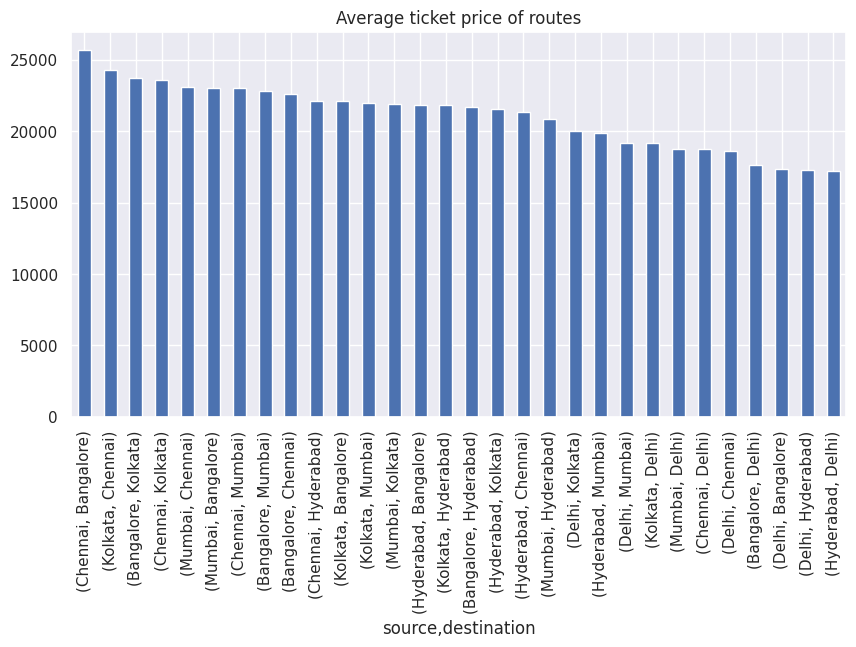

In [27]:

plt.figure(figsize=(10, 5))

# 1: Price
df.groupby(['source','destination'])['price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average ticket price of routes")
plt.show()